# Emoji–Label Association Analysis using Dirichlet-Smoothed Log-Odds

While frequency analysis shows the most commonly used emojis, it does not reveal which emojis are uniquely associated with specific labels. To address this limitation, **Dirichlet-smoothed log-odds scores with z-score normalization** are computed to identify emojis that are disproportionately associated with each label relative to the overall distribution. This approach follows the method introduced in [Monroe et al. (2008)](https://doi.org/10.1093/pan/mpn018).

A corpus-level prior, derived from overall emoji frequency, stabilizes the estimates and reduces the influence of rare emojis. The resulting z-scores enable meaningful comparison of association strength across emojis and labels.


In [1]:
import pandas as pd
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.io as pio
pio.renderers.default = "browser"

df = pd.read_csv('emoji.csv')
emoji_df = pd.read_csv('emoji_exploded.csv')

In [2]:
df.head()

,Unnamed: 0,text,language,label,char_len,word_len,emojis,emoji_count,has_emoji
0,0,@Charlie_Corley @Kristine1G @amyklobuchar @Sty...,en,litigious,155,22,[],0,False
1,1,#BadBunny: Como dos gotas de agua: Joven se di...,es,negative,123,19,[],0,False
2,2,https://t.co/YJNiO0p1JV Flagstar Bank disclose...,en,litigious,114,13,[],0,False
3,3,Rwanda is set to host the headquarters of Unit...,en,positive,211,25,[],0,False
4,4,OOPS. I typed her name incorrectly (today’s br...,en,litigious,303,27,[],0,False


In [3]:
# build emoji count table
emoji_counts = pd.crosstab(emoji_df["emojis"], emoji_df["label"])
emoji_counts = emoji_counts.fillna(0)

## Frequency Threshold

Highly frequent emojis (e.g., 😂) tend to appear across many labels. Moreover,very rare emojis introduce noise and instability in statistical estimation.

To balance reliability and coverage, the distribution of emoji frequencies is examined and a minimum frequency threshold is applied prior to computing log-odds scores.

In [4]:
emoji_freq = (
    emoji_df["emojis"]
    .value_counts()
    .sort_values(ascending=False)
)

emoji_freq.describe()

count     2471.000000
mean       120.957102
std        829.627266
min          1.000000
25%          3.000000
50%         10.000000
75%         39.000000
max      28717.000000
Name: count, dtype: float64

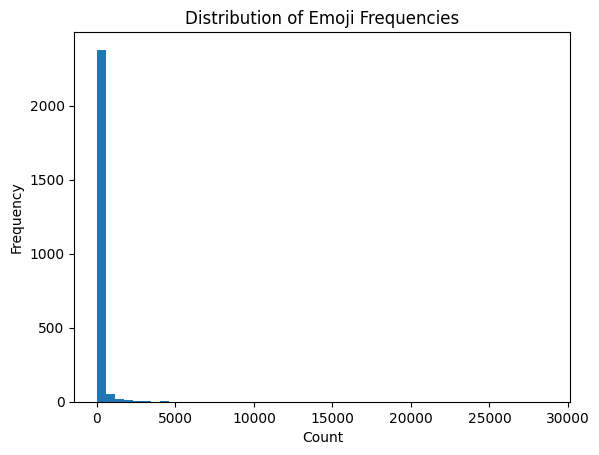

In [5]:
plt.figure()

plt.hist(emoji_freq, bins=50)

#plt.xscale('log')  
plt.title("Distribution of Emoji Frequencies")
plt.xlabel("Count")
plt.ylabel("Frequency")

plt.show()

The frequency distribution is highly skewed: most emojis occur only a small number of times, while a small subset appears extremely frequently (e.g., max = 28,717).

To address this long-tail pattern, both frequency filtering and smoothing are used in the log-odds analysis.

In [6]:
thresholds = [5, 10, 20, 50, 100, 200]
total = emoji_freq.sum()

data = []
for t in thresholds:
    count = (emoji_freq >= t).sum()
    coverage = emoji_freq[emoji_freq >= t].sum() / total
    data.append([t, count, coverage])

freq = pd.DataFrame(data, columns=["Min Frequency", "Emoji Count", "Usage Coverage"])
freq["Usage Coverage"] = freq["Usage Coverage"].apply(lambda x: f"{x:.2%}")
freq

,Min Frequency,Emoji Count,Usage Coverage
0,5,1611,99.42%
1,10,1244,98.60%
2,20,883,96.95%
3,50,555,93.56%
4,100,368,89.33%
5,200,227,82.53%


In [7]:
min_freq = 20

valid_emojis = emoji_freq[emoji_freq >= min_freq].index

filtered_counts = emoji_counts.loc[valid_emojis]

print(f"Emojis before: {emoji_counts.shape[0]}")
print(f"Emojis after: {filtered_counts.shape[0]}")

Emojis before: 2471
Emojis after: 883


To focus the analysis on emojis with sufficient representation, a minimum frequency threshold of 20 was set for log-odds analysis. This reduces the number of unique emojis from 2,471 to 883, while still capturing 96.95% of all emoji occurrences. The analysis therefore focuses on frequent emojis without discarding the majority of the data.

## Dirichlet-Smoothed Log-Odds

The goal is to quantify how strongly each emoji is associated with a given label relative to all other labels. Naive log-odds ratios are often unstable for low-frequency emojis. To address this, **Dirichlet smoothing** is applied, incorporating a prior based on the overall emoji distribution.


For each emoji–label pair:
- Smoothed log-odds are computed using counts within the label versus all other labels
- A variance estimate is derived from the Dirichlet prior
- A **z-score** is calculated by standardizing the log-odds with respect to its variance

The z-score enables comparison across emojis by accounting for both effect size and uncertainty.

This method follows [Monroe et al. (2008)](https://doi.org/10.1093/pan/mpn018), a standard approach for identifying discriminative features in text.

### Prior Distribution

A Dirichlet prior is constructed using the overall frequency of each emoji in the corpus. This prior represents the background distribution and regularizes estimates, particularly for low-frequency emojis.

In [8]:
# total counts per emoji
emoji_totals = filtered_counts.sum(axis=1)

# convert to probability distribution
prior = emoji_totals / emoji_totals.sum()

### Log-Odds and Z-Score Computation

The function below computes Dirichlet-smoothed log-odds and corresponding z-scores for each emoji–label pair.

The resulting matrix:
- Rows correspond to emojis
- Columns correspond to labels
- Values represent z-scores, where higher values indicate stronger association

In [9]:
def compute_log_odds_dirichlet(counts_df, prior):
    
    labels = counts_df.columns
    vocab = counts_df.index
    
    results = pd.DataFrame(index=vocab, columns=labels)
    
    alpha = prior.sum()
    
    for label in labels:
        
        counts_label = counts_df[label]
        counts_other = counts_df.drop(columns=label).sum(axis=1)
        
        n_label = counts_label.sum()
        n_other = counts_other.sum()
        
        # log-odds with prior
        log_odds_label = np.log(
            (counts_label + prior) /
            (n_label + alpha - (counts_label + prior))
        )
        
        log_odds_other = np.log(
            (counts_other + prior) /
            (n_other + alpha - (counts_other + prior))
        )
        
        delta = log_odds_label - log_odds_other
        
        # variance
        var = 1 / (counts_label + prior) + 1 / (counts_other + prior)
        
        z_score = delta / np.sqrt(var)
        
        results[label] = z_score
    
    return results

In [10]:
z_scores = compute_log_odds_dirichlet(filtered_counts, prior)

z_scores.head()

label,litigious,negative,positive,uncertainty
emojis,,,,
😂,0.467411,48.874868,-77.625376,49.462555
😭,-24.790969,60.477759,-30.663401,-5.861009
🤣,19.175115,38.134213,-46.683553,1.631698
❤️,-19.574288,-20.051946,41.207308,-12.857203
🔥,13.925361,-18.562036,22.478553,-19.222777


### Concentration

In addition to z-scores, **concentration** is computed as the proportion of an emoji’s total occurrences that fall within a given label:

concentration = count_in_label / total_count

While z-scores capture statistical distinctiveness, concentration provides an intuitive measure of how strongly an emoji is concentrated within a label.

### Top Emojis per Label

For each label, emojis are ranked by z-score. The output includes:
- Total count
- Count within the label
- Concentration

This combination provides both a statistical and interpretable view of emoji–label associations.

In [11]:
top_k = 10

all_tables = []

for label in z_scores.columns:
    
    top = z_scores[label].sort_values(ascending=False).head(top_k)
    
    df_out = pd.DataFrame({
        "z_score": top,
        "total_count": filtered_counts.loc[top.index].sum(axis=1),
        "count_in_label": filtered_counts.loc[top.index, label],
    })
    
    df_out["concentration"] = (
        df_out["count_in_label"] / df_out["total_count"]
    )
    
    df_out["label"] = label
    
    all_tables.append(df_out)

# combine everything
final_df = pd.concat(all_tables)

# clean multi-index
final_df = final_df.set_index("label", append=True).swaplevel()

# final sort
final_df = final_df.sort_index()
final_df["z_score"] = final_df["z_score"].round(2)
final_df["concentration"] = final_df["concentration"].round(2)
final_df = final_df.sort_values(by=["label", "z_score"], ascending=[True, False])

final_df

z_score  total_count  count_in_label  concentration
label       emojis                                                     
litigious   🚨         37.33         1525             798           0.52
            🤡         26.69         1641             634           0.39
            📝         24.96          386             297           0.77
            ✅         24.01         1983             669           0.34
            🆕         20.53          258             206           0.80
            🔵         20.25          367             214           0.58
            😡         19.25         1266             429           0.34
            🤣         19.18        14454            2805           0.19
            🛑         18.30          216             158           0.73
            ✍️        17.30          267             156           0.58
negative    😭         60.48        18545            7982           0.43
            😂         48.87        28717           10338           0.36
            🤣         38.13        14454            5482           0.38
            💔         36.93         2147            1349           0.63
            💀         21.96         2286            1032           0.45
            😢         21.20         1197             632           0.53
            🟩         18.46          863             463           0.54
            ⬛         15.04          558             302           0.54
            🙄         14.37         2667             983           0.37
            🥲         14.31         1123             491           0.44
positive    ❤️        41.21         7799            5058           0.65
            ✨         38.95         3833            2872           0.75
            😍         35.99         4090            2892           0.71
            🥰         27.19         3094            2058           0.67
            💜         27.07         2635            1812           0.69
            🎉         25.72         1458            1144           0.78
            🤩         25.17         1512            1157           0.77
            💙         23.26         2092            1417           0.68
            💕         22.58         2156            1433           0.66
            🔥         22.48         5452            3084           0.57
uncertainty 😂         49.46        28717            8551           0.30
            🤔         30.23         4241            1617           0.38
            🥴         20.53         1070             490           0.46
            😉         16.80         1947             677           0.35
            😳         15.78         1489             536           0.36
            😺         15.72          200             155           0.78
            🙃         15.35         1097             421           0.38
            🤷🏻‍♀️     15.22          428             219           0.51
            🥺         15.13         3430            1017           0.30
            😔         14.22         1720             571           0.33

In [12]:
df_plot = final_df.reset_index()  

fig = px.scatter(
    df_plot,
    x="z_score",
    y="concentration",
    size="total_count",
    text="emojis",  
    facet_col="label",
    facet_col_wrap=2,
    title="Emoji Associations by Label",
    hover_data={
        "emojis": True,
        "z_score": True,
        "concentration": True,
        "total_count": True
    }
)

fig.update_traces(textposition="top center")

fig.update_layout(
    xaxis_title="Z-score",
    yaxis_title="Concentration"
)

fig.show()

fig.write_html("outputs/emoji_label_association.html")
fig.write_image("outputs/emoji_label_association.png")

![emoji-label association](outputs/emoji_label_association.jpg)

The results show clear differences in emoji usage across labels. Z-scores capture how strongly an emoji is linked to a label, while concentration shows how much it is used within that label.

- **Positive:** Emojis like ❤️, ✨, and 😍 are both strongly linked to the label and mostly used there, especially those related to celebration and affection.
- **Negative:** Emotion-heavy emojis (e.g., 😭, 😂, 💔) are common and strongly linked, but some are also used across other labels.
- **Litigious:** Emojis are less frequent overall, but a few (e.g., 🚨, 🤡, 📝) are closely associated to this category.
- **Uncertainty:** Emoji usage is more mixed. Some emojis are linked to the label (e.g., 🤔), but most appear across multiple labels rather than being specific to one.

Overall, emojis that are both strongly linked to a label (high z-score) and mostly used within it (high concentration) are the strongest indicators.